# Double-blind evaluation — Model Owner

| Actor | Email | Role |
|-------|-------|------|
| **Enclave** | `ENCLAVE_EMAIL` | Tinfoil Container that runs the evaluation |
| **Benchmark owner** | `BENCHMARK_OWNER_EMAIL` | Owns the private prompt set |
| **Model owner** | `MODEL_OWNER_EMAIL` | Owns the private LoRA adapter |

**The setting.** A benchmark owner wants to know how a model behaves on prompts it has never
seen. A model owner is willing to be measured but will not hand over the weights. Neither will show
the other what they hold, and neither trusts the machine in the middle.

Both connect to an [enclave](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-enclave) — a
sealed environment whose contents nobody, including whoever runs the hardware, can read. Each
uploads their half. Nothing runs until **both** owners approve the exact code, and the enclave
proves what it is before either of them uploads anything.

This is the flow from [tinfoilsh/double-blind-eval](https://github.com/tinfoilsh/double-blind-eval),
carried out entirely over PySyft. The enclave is a [Tinfoil
Container](https://docs.tinfoil.sh/containers/overview), and the attestation is checked against the
measurement published for a signed release of its config.

We hold the model. We approve the evaluation, and we do not get to see its results — only the
benchmark owner does. That asymmetry is the point: we agreed to be measured, not to learn what the
measurement was made of.

## Setup

In [ ]:
!uv pip install -Uq "syft-enclave[tinfoil] @ git+https://github.com/OpenMined/PySyft.git@dev#subdirectory=packages/syft-enclave"

In [ ]:
import json
import random
import tempfile
from pathlib import Path

from syft_enclaves import login_do
from syft_enclaves.attestation.tinfoil import TinfoilAppraisalPolicy

In [ ]:
ENCLAVE_EMAIL         = "enclave@openmined.org"
BENCHMARK_OWNER_EMAIL = "benchmark_owner@openmined.org"
MODEL_OWNER_EMAIL     = "model_owner@openmined.org"

# What the enclave is checked against. TINFOIL_TAG and IMAGE_DIGEST come from
# whoever deployed it: `just tinfoil-release` prints the digest, and the tag is
# the config release it was deployed from.
TINFOIL_REPO = "OpenMined/syft-enclave-tinfoil"
TINFOIL_TAG  = "v0.1.16"
IMAGE_DIGEST = "sha256:2e3cab9c3e1c80401d9cd062381226971710252cb1c166e52524d90e58b2bdf0"

print(f"  Enclave: {ENCLAVE_EMAIL}")
print(f"  Benchmark owner: {BENCHMARK_OWNER_EMAIL}  |  Model owner: {MODEL_OWNER_EMAIL}")
print(f"  Verifying against {TINFOIL_REPO} {TINFOIL_TAG}")

## Step 0 — Log in as Model Owner

Colab authenticates us to Google Drive, which is how every party in this demo reaches every other
one. Nothing here talks to the enclave yet.

In [ ]:
CRYPTO_KEYS_PATH = None
# NOTE: Re-storing Private Key from local_file, if you have it, uncomment the following line and upload the file.
# from google.colab import files; files.upload()
# CRYPTO_KEYS_PATH = "crypto_keys.json"

model_owner = login_do(encryption=True, crypto_keys_path=CRYPTO_KEYS_PATH)
print(f"  Model owner : {model_owner.email}")

In [ ]:
# # Optionally, to start from a clean SyftBox
# model_owner.delete_syftbox()
# model_owner._rds.peer_manager.write_own_version()

## Step 1 — Connect to the enclave and to the benchmark owner

We ask the enclave to peer with us, which is what lets us send it our weights. The benchmark owner
sends us a peer request from their notebook; approving it lets them read our public model card, and
nothing else.

In [ ]:
model_owner.add_peer(ENCLAVE_EMAIL)
print(f"  Peer request sent to the enclave ({ENCLAVE_EMAIL})")

### Step 1.1 — Approve the benchmark owner

Re-run the cell below until their request appears, then approve it. `peer_must_exist=False` lets us
approve a request that has arrived before our own view of them has caught up.

In [ ]:
model_owner.peers

In [ ]:
model_owner.approve_peer_request(BENCHMARK_OWNER_EMAIL, peer_must_exist=False)
print("  Benchmark owner approved")

## Step 2 — Attest the enclave

Before uploading anything, we check what we are uploading it to. The enclave holds a key that never
leaves the hardware, and it serves a report signed under that key over a connection pinned to it. We
compare that report against the measurement published for `TINFOIL_TAG` — a signed GitHub release of
the enclave's config — and against the facts we expect: the container image digest, which datasite
the enclave runs as, and which two owners have to approve a job.

Every one of those has to be pinned. Unpinned, the attestation would prove a genuine enclave booted
a signed config, but not that the config was the one we reviewed. Tinfoil is not in the trust path,
and neither are we to each other.

In [ ]:
policy = TinfoilAppraisalPolicy(
    repo=TINFOIL_REPO,
    release_tag=TINFOIL_TAG,
    expected_image_digest=IMAGE_DIGEST,
    expected_data_owners=[BENCHMARK_OWNER_EMAIL, MODEL_OWNER_EMAIL],
    expected_email=ENCLAVE_EMAIL,
    # The measured config pins no SYFT_VERSION, so there is nothing to compare.
    expected_syft_version=None,
)

result = model_owner.attest_peer(ENCLAVE_EMAIL, policy=policy)

if result is None:
    print(" 🟠 The enclave published no attestation yet. Wait a moment and re-run this cell.")
else:
    result.print_checklist()
    print()
    print(f"  Bound to the report: {result.verified_key_bundle is not None}")

## Step 3 — Fetch the private adapter

Our model is a [PEFT](https://huggingface.co/docs/peft) LoRA adapter: a small set of weights that
adjusts a public base model. In a real run these would be weights we trained and never published.
Here we borrow a public adapter to stand in for one, the same way the double-blind-eval demo does.

In [ ]:
# The adapter from the double-blind-eval demo: a public LoRA standing in for a
# private one. It targets google/gemma-4-31B-it, which needs a GPU-shaped enclave
# (`gpus:` in tinfoil-config.yml, which means a new measured config release).
# ADAPTER_REPO = "Kobarac/gemma4-31b-factual-tool-selector-lora"

# On the enclave's current shape — 2 CPUs, 8 GB, no GPU — use a small pair that
# runs in software. Same two-file layout, same flow.
ADAPTER_REPO = "zjudai/flowertune-general-nlp-lora-tinyllama-1.1b-chat-v1.0"
ADAPTER_REV = "main"
ADAPTER_DIR = Path("dbe-adapter")

print(f"  Adapter: {ADAPTER_REPO}@{ADAPTER_REV}")

In [ ]:
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

# A PEFT LoRA directory is two files: the config and the weights.
for name in ("adapter_config.json", "adapter_model.safetensors"):
    url = f"https://huggingface.co/{ADAPTER_REPO}/resolve/{ADAPTER_REV}/{name}"
    !curl -sfL "{url}" -o "{ADAPTER_DIR}/{name}"
    print(f"  fetched {name}")

## Step 4 — Upload the model

We upload the adapter into the enclave. The **private** side is the weights, shared only with the
enclave. The **mock** side is a model card: the base model, the rank, the size. That is all the
benchmark owner ever sees of our model.

Uploading grants nothing on its own. The weights are used once, by a job we approve, and they are
gone when the enclave restarts — Tinfoil Containers have no persistent disk.

In [ ]:
adapter_config = json.loads((ADAPTER_DIR / "adapter_config.json").read_text())
BASE_MODEL = adapter_config["base_model_name_or_path"]
LORA_RANK = adapter_config["r"]


def create_model_card() -> Path:
    """The public half: what the benchmark owner may know about our model."""
    tmp = Path(tempfile.mkdtemp()) / f"model-card-{random.randint(1, 1_000_000)}"
    tmp.mkdir(parents=True, exist_ok=True)
    path = tmp / "model_card.txt"
    weights = ADAPTER_DIR / "adapter_model.safetensors"
    path.write_text("\n".join([
        "Private LoRA adapter",
        "====================",
        f"Base model     : {BASE_MODEL}",
        f"LoRA rank      : {LORA_RANK}  (alpha {adapter_config['lora_alpha']})",
        f"Target modules : {', '.join(sorted(adapter_config['target_modules']))}",
        f"Size           : {weights.stat().st_size / 1e6:.1f} MB",
        "",
        "The weights are not shared. They go to the enclave and nowhere else.",
        "",
    ]))
    return path


model_card = create_model_card()
print(model_card.read_text())

In [ ]:
model_owner.create_dataset(
    name="dbe_adapter",
    mock_path=model_card,
    private_path=ADAPTER_DIR,
    summary=f"Private LoRA adapter for {BASE_MODEL} — rank {LORA_RANK}",
    users=[BENCHMARK_OWNER_EMAIL, ENCLAVE_EMAIL],
)
print("  Created 'dbe_adapter'")

In [ ]:
# Send the weights to the enclave, and only to the enclave.
model_owner.share_private_dataset("dbe_adapter", ENCLAVE_EMAIL)
print("  Private adapter shared with the enclave")

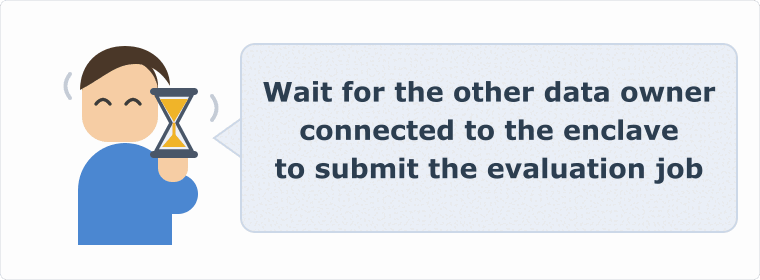

## Step 5 — Wait for the evaluation job

The benchmark owner submits the job that runs our model on their prompts. The enclave distributes it
to both of us for approval. Re-run the cell below until it appears.

In [ ]:
job = next((j for j in model_owner.jobs if j.name == "dbe_eval_job"), None)

if job is not None and not job.can_approve:
    print(" 🟠 Job 'dbe_eval_job' is here, but the enclave has not sent our approval file yet. Wait a moment and re-run this cell.")
elif job is None:
    print(" 🟠 Job 'dbe_eval_job' not visible yet — the benchmark owner may not have submitted it. Wait a moment and re-run this cell.")
else:
    print(f" ✅ Model owner sees 'dbe_eval_job'  status={job.status}")

### Step 5.1 — Read it

This is the code that will touch our weights, so read it properly. Two things are worth checking:
that it reads our adapter through `resolve_dataset_files_path` and uses it for nothing but
generation, and that it writes only the completions and timings to `outputs/` — no weights, no
tensors.

`share_results_with_do=False` in the submission is what routes the output to the benchmark owner
alone. We are approving a run we will not see the result of.

In [ ]:
job

## Step 6 — Approve the job

Our approval is one of two. The benchmark owner approves from their notebook, and the run starts the
moment the second approval lands. Either order works; until both are in, the status stays `pending`
and nothing has touched our weights.

In [ ]:
model_owner.approve_job(job)
print("  Model owner approved")

## Step 7 — We do not get the result

The enclave runs the evaluation and sends the output to whoever submitted the job. That is the
benchmark owner, so our copy of the job has no outputs and never reaches `done` — we approved the
run and learned nothing from it.

That is what we agreed to. The enclave proved what it was running before we uploaded anything, and
it ran the code we both read, so the benchmark owner's completions came from our adapter and nothing
else. Neither of us learned the other's half.

In [ ]:
job = next(j for j in model_owner.jobs if j.name == "dbe_eval_job")
print(f"  Job status   : {job.status}")
print(f"  Output files : {job.output_paths}")

---

The benchmark owner now has completions from your model on prompts you never saw, and you never saw
their prompts. Nobody, including whoever runs the hardware, saw both halves.